<a href="https://colab.research.google.com/github/islam281/Ultimate-Customer-Churn-Prediction-Challenge/blob/main/house_price_preduction_done.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler




In [37]:
# --- 1. Load data (عدّل path/اسم الملف حسب dataset بتاعتك) ---
df = pd.read_csv("/content/Housing.csv")  # example filename
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


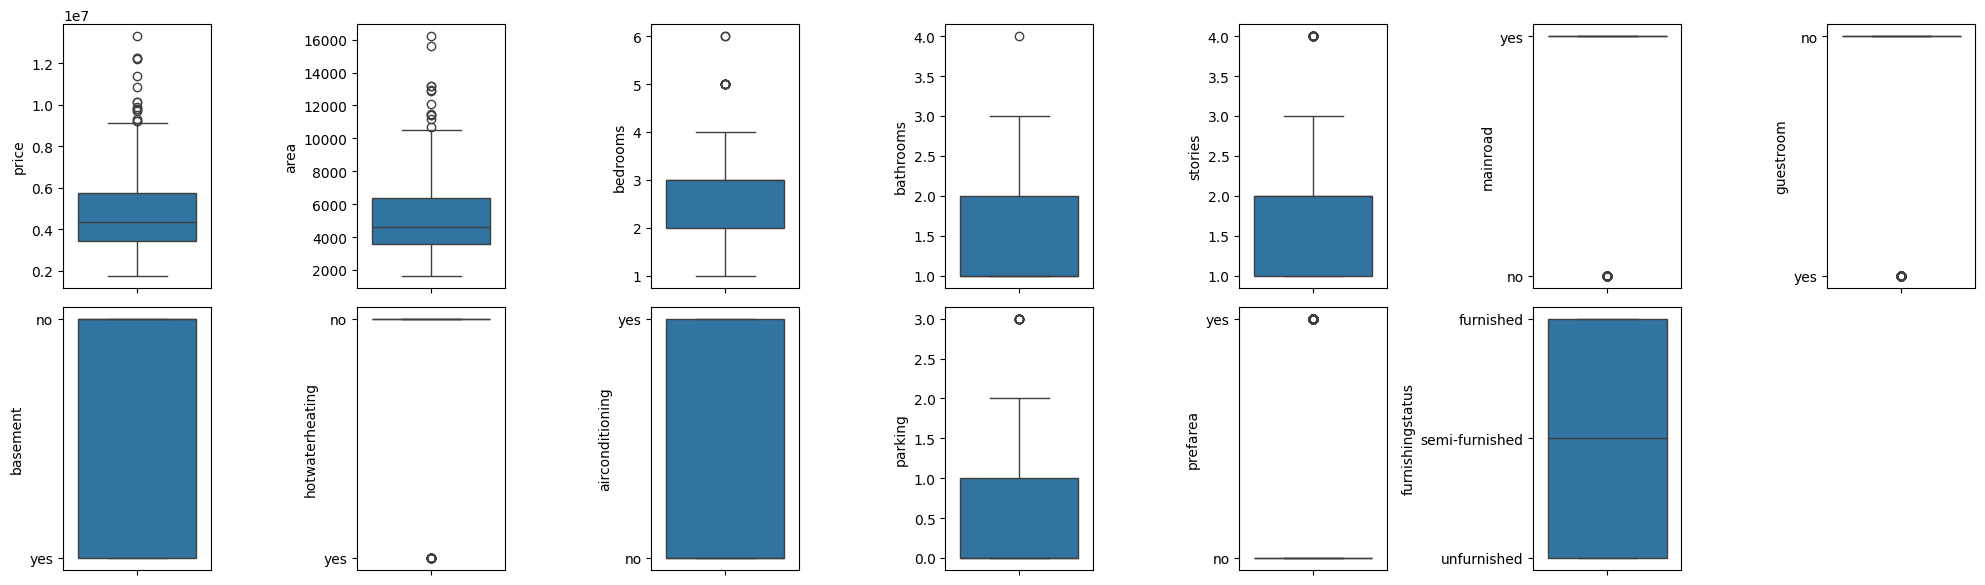

In [38]:
fig=plt.figure(figsize=(20,20))

for index,col in enumerate(df.columns):
    plt.subplot(7,7,index+1)
    sns.boxplot(df[col])

plt.tight_layout(pad=1)

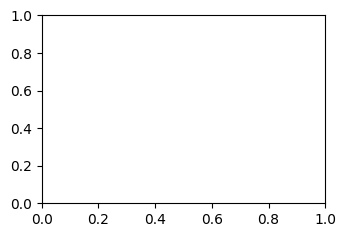

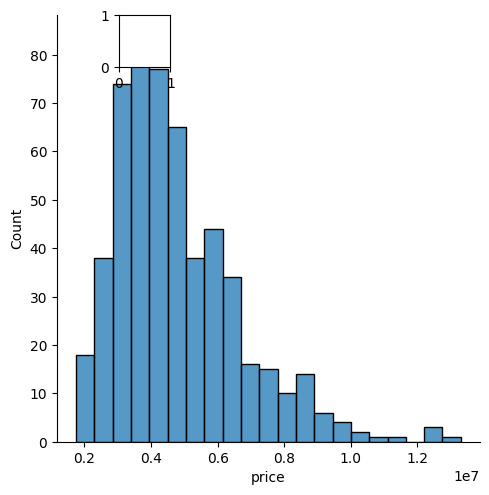

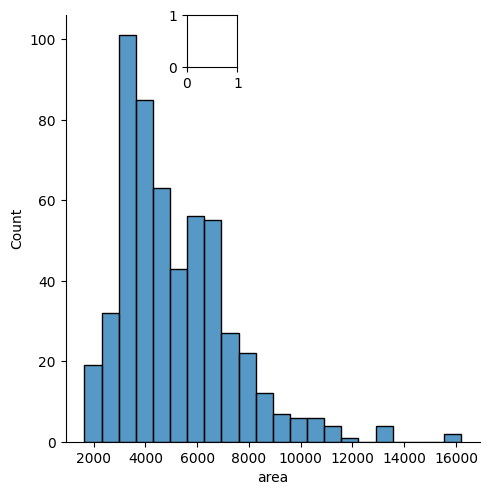

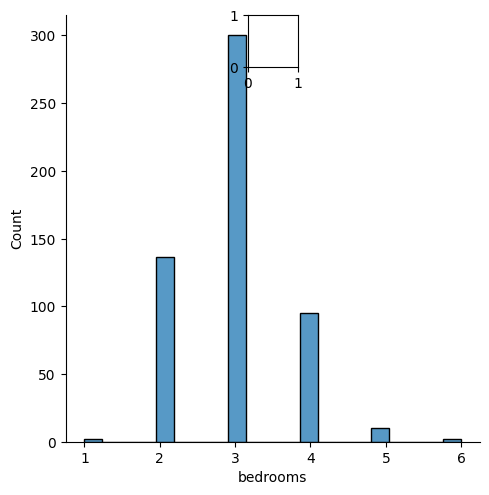

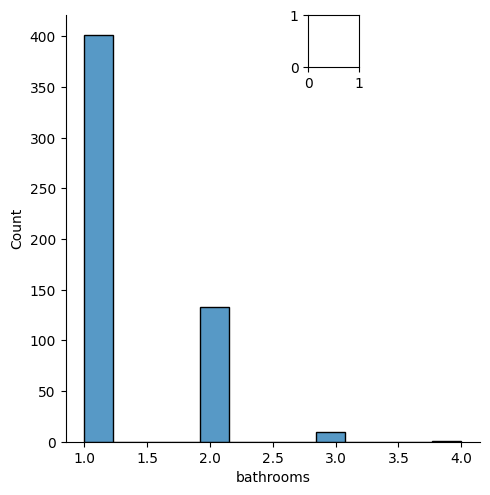

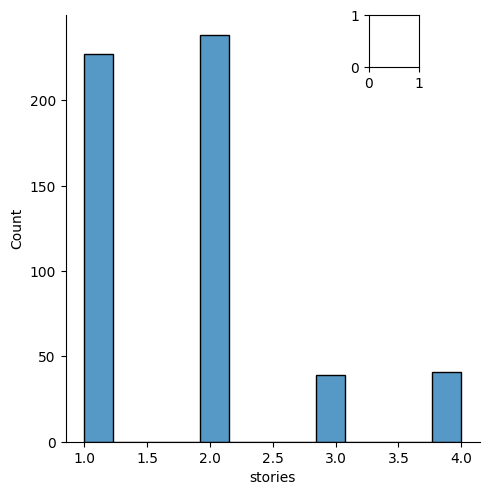

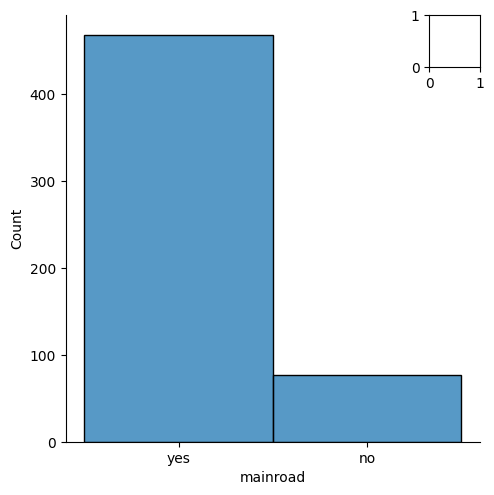

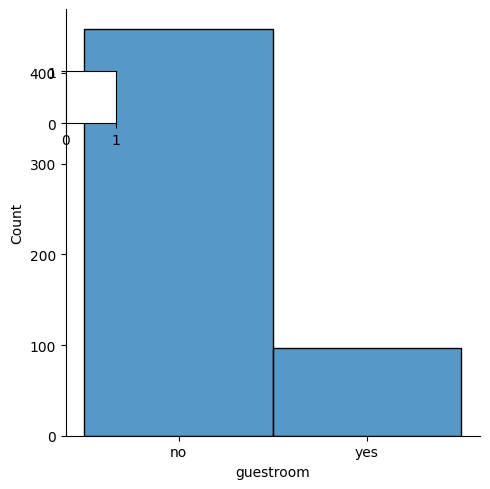

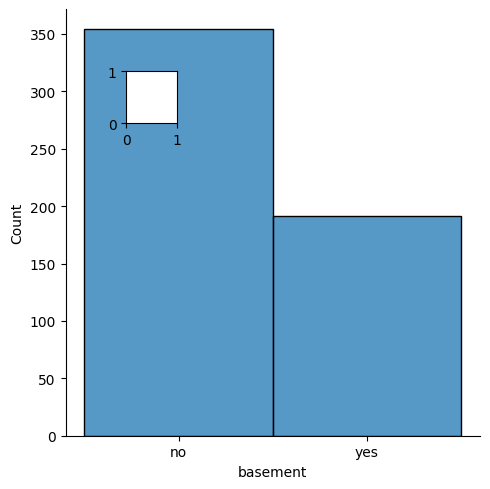

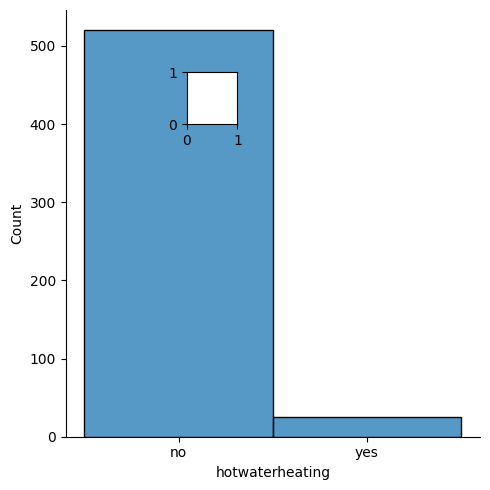

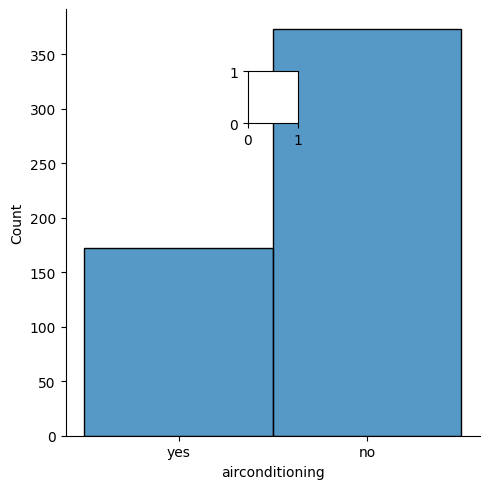

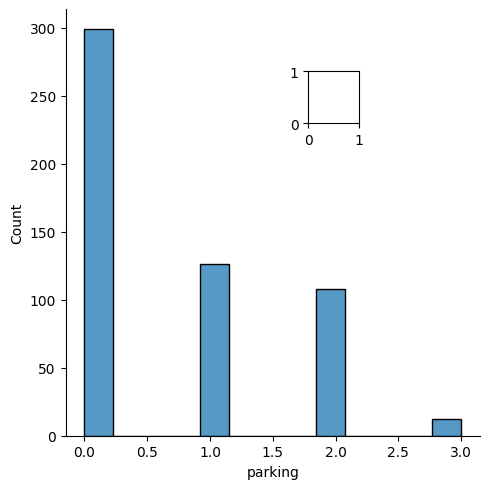

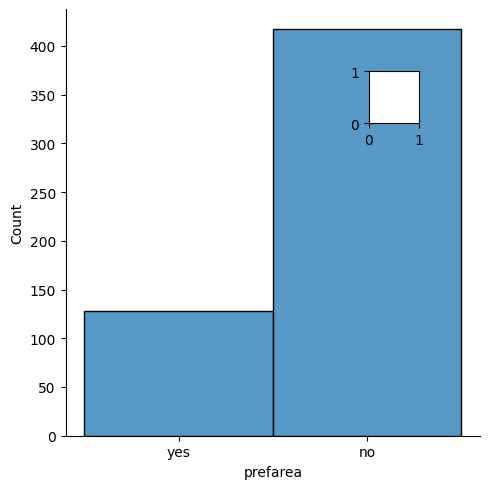

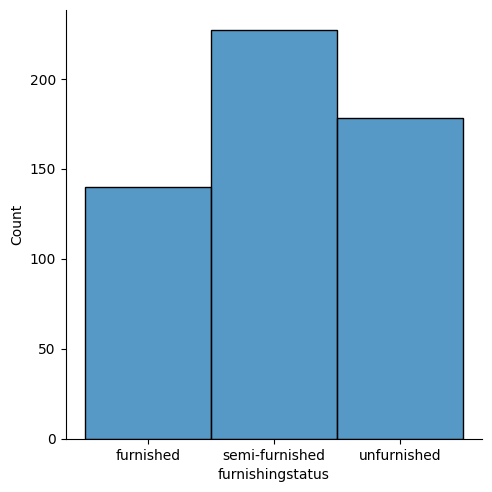

In [39]:
fig=plt.figure(figsize=(30,20))

for index,col in enumerate(df.columns):
    plt.subplot(7,7,index+1)
    sns.displot(df[col])

plt.tight_layout(pad=1)

In [40]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [41]:
df.dtypes

,0
price,int64
area,int64
bedrooms,int64
bathrooms,int64
stories,int64
mainroad,object
guestroom,object
basement,object
hotwaterheating,object
airconditioning,object


In [42]:
df.duplicated().sum()

np.int64(0)

In [43]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [44]:
X = df.drop(columns=["price"])
y = df["price"]

In [45]:
''' # ================================
#  Ensure ALL columns are numeric
# ================================
X = X.apply(pd.to_numeric, errors='coerce')
 '''

" # ================================\n#  Ensure ALL columns are numeric\n# ================================\nX = X.apply(pd.to_numeric, errors='coerce')\n "

In [46]:
# قسّم البيانات
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [55]:

# ----------------------------
#  Encode Yes/No binary columns
# ----------------------------
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating',
                  'airconditioning', 'prefarea']
for col in binary_cols:
    df[col] = df[col].map({"Yes": 1, "No": 0})


In [48]:
# ----------------------------
# One-hot encode the rest of categorical columns
# ----------------------------
onehot_cols = ["furnishingstatus"]
df = pd.get_dummies(df, columns=onehot_cols, drop_first=True)


In [57]:
scaler = RobustScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


ValueError: could not convert string to float: 'yes'